# NB-3 — Designing kernels for the data you actually have

**Roadmap:** `resources/topics_guide.md`, Part 3.

**The problem this solves.** NB-1 and NB-2 assumed $x \in \mathbb{R}^d$ and reached for an RBF. Real exposome data is nothing like that. Sex and site are categorical; education is ordinal; a week-by-week pollution series is a whole curve; exposures arrive in blocks defined by their source; mobility is a network. Feeding all of that to one RBF throws away every bit of the structure.

The entire toolkit is three closure rules from NB-1 §1.4: **sums, products and positive scalings of valid kernels are valid**. Everything below is assembled from those three moves, and every construction is checked for positive-definiteness before it is used.

## What will you be able to do by the end?

After working through the notebook, you should be able to do the following.

- Build kernels for **categorical**, **ordinal** and **functional** inputs, and know where each stops being valid.
- Explain why a categorical kernel has a hard lower bound on its off-diagonal correlation.
- Use an **additive** kernel to decompose an outcome into per-source contributions, and recover each one separately.
- Say what an additive kernel assumes, and what it therefore cannot represent.
- Share strength across correlated outcomes with a **multi-task (ICM)** kernel.
- Interpolate between additive and fully-interacting models with **ANOVA** kernels, and read a pairwise interaction off the fit.
- Build a kernel on a **graph** from its Laplacian, and say why indirect paths matter.
- Compose all of the above into one covariance and verify it is still positive semi-definite.

## What should already be familiar?

You need NB-1 §1.4 (the PSD closure rules — used on almost every page here) and NB-2 §2.2/§2.4 (GP regression and the marginal likelihood, which is how we compare competing kernel designs).

No new mathematics is introduced. What is new is *judgement*: most of this notebook is about matching a covariance to a data structure, which is a modelling skill rather than a computational one. Allow about ninety minutes.

## What route will we take?

| Part | Question | Main output |
|---:|---|---|
| 3.1 | What if the exposure is not a number? | Categorical, ordinal and functional kernels |
| 3.2 | Can we separate the contribution of each source? | An additive kernel with per-component posteriors |
| 3.3 | What if we measured several outcomes? | An ICM kernel that borrows strength |
| 3.4 | How do we allow interactions without allowing everything? | ANOVA kernels and an isolated pairwise term |
| 3.5 | What if similarity is a network, not a distance? | Laplacian and diffusion kernels |
| 3.6 | Can we put it all in one covariance? | A composed mixed-type kernel, verified PSD |

§3.2 and §3.4 are the two that carry the most weight later — they are the structure behind BKMR and multi-pollutant models in NB-6.

Seven **Try it** boxes ask for an answer in your own words. §3.6 asks you to design a kernel for a cohort of your own, which is the real test of this notebook.

In [1]:
import numpy as np
import nbkit as nk
from scipy.optimize import minimize

plt = nk.set_style()
rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True)

In [2]:
# The GP from Part 2, reused throughout. Kernels here take precomputed Gram matrices or
# raw arrays, so this version accepts a callable k(A, B).
class GP:
    def __init__(self, kernel, noise=0.1):
        self.kernel, self.noise = kernel, noise

    def fit(self, X, y):
        self.X_, self.y_mean_ = X, y.mean()
        yc = y - self.y_mean_
        K = self.kernel(X, X)
        K = 0.5 * (K + K.T) + self.noise**2 * np.eye(len(y))
        self.L_, _ = nk.jitter_chol(K)
        self.alpha_ = np.linalg.solve(self.L_.T, np.linalg.solve(self.L_, yc))
        self.yc_ = yc
        return self

    def predict(self, Xs):
        Ks = self.kernel(self.X_, Xs)
        mu = Ks.T @ self.alpha_ + self.y_mean_
        V = np.linalg.solve(self.L_, Ks)
        var = np.diag(self.kernel(Xs, Xs)).copy() - np.sum(V**2, 0)
        return mu, np.maximum(var, 0.0)

    def lml(self):
        return float(-0.5 * self.yc_ @ self.alpha_
                     - np.log(np.diag(self.L_)).sum()
                     - 0.5 * len(self.yc_) * np.log(2 * np.pi))

---
## 3.1 What if the exposure is not a number?

### Categorical

For an unordered factor the natural kernel says "same level or not":

$$
k_{\text{cat}}(a, a') = \begin{cases} 1 & a = a' \\ \rho & a \ne a'\end{cases}
$$

This is PSD for $-\tfrac{1}{L-1} \le \rho \le 1$ ($L$ levels). $\rho = 0$ treats levels as
unrelated; $\rho \to 1$ pools them. Crucially this is **not** the same as one-hot encoding
plus an RBF — that imposes a fixed geometry, whereas $\rho$ is a hyperparameter the marginal
likelihood can learn.

### Ordinal

Education (`none < primary < secondary < tertiary`) has order but no meaningful spacing.
Map levels to positions on a line and use an RBF on those positions; the *spacings* can be
learned. A lazy integer coding asserts that primary→secondary equals secondary→tertiary,
which is usually false.

### Functional

A whole exposure trajectory $x(t)$ (weekly PM$_{2.5}$ over pregnancy) is one observation.
The natural kernel uses the $L^2$ distance between curves,
$k(x, x') = \exp\big(-\tfrac{1}{2\ell^2}\int (x(t)-x'(t))^2\,dt\big)$, approximated by a
weighted sum over the observed grid. This is the entry point to Part 6.

In [3]:
def categorical_kernel(a, b, rho=0.0):
    """k = 1 if same level else rho. PSD for rho in [-1/(L-1), 1]."""
    a = np.asarray(a).ravel()[:, None]
    b = np.asarray(b).ravel()[None, :]
    return np.where(a == b, 1.0, rho)


def ordinal_kernel(a, b, positions, lengthscale=1.0):
    """Map ordered levels to learned positions on a line, then RBF."""
    pos = np.asarray(positions, float)
    pa = pos[np.asarray(a).ravel().astype(int)][:, None]
    pb = pos[np.asarray(b).ravel().astype(int)][:, None]
    return nk.rbf_kernel(pa, pb, lengthscale=lengthscale)


def functional_kernel(A, B, lengthscale=1.0, variance=1.0, weights=None):
    """RBF on the L2 distance between sampled curves. A: (n, T), B: (m, T)."""
    A, B = np.atleast_2d(A), np.atleast_2d(B)
    w = np.ones(A.shape[1]) if weights is None else np.asarray(weights, float)
    Aw, Bw = A * np.sqrt(w), B * np.sqrt(w)
    d2 = (np.sum(Aw**2, 1)[:, None] + np.sum(Bw**2, 1)[None, :] - 2 * Aw @ Bw.T)
    return variance * np.exp(-0.5 * np.maximum(d2, 0.0) / lengthscale**2)


# --- PSD checks, including the boundary where the categorical kernel stops being valid ---
levels = rng.integers(0, 4, size=50)
print("categorical kernel, 4 levels -> rho must be >= -1/3:")
for rho in [1.0, 0.5, 0.0, -0.33, -0.40, -0.8]:
    nk.psd_report(f"  rho = {rho:+.2f}", categorical_kernel(levels, levels, rho))

print()
ord_lv = rng.integers(0, 4, size=50)
nk.psd_report("ordinal (even spacing)", ordinal_kernel(ord_lv, ord_lv, [0, 1, 2, 3]))
nk.psd_report("ordinal (learned spacing)", ordinal_kernel(ord_lv, ord_lv, [0, 0.4, 1.8, 2.0]))

curves = rng.normal(size=(50, 30)).cumsum(1)
_ = nk.psd_report("functional (L2 on curves)", functional_kernel(curves, curves, lengthscale=5.0))

categorical kernel, 4 levels -> rho must be >= -1/3:
  rho = +1.00                        lambda_min = -1.110e-16   rank   1/50   PSD  ok
  rho = +0.50                        lambda_min = -6.637e-15   rank   4/50   PSD  ok
  rho = +0.00                        lambda_min = -3.661e-15   rank   4/50   PSD  ok
  rho = -0.33                        lambda_min = -4.553e-15   rank   4/50   PSD  ok
  rho = -0.40                        lambda_min = -2.362e+00   rank   3/50   NOT PSD
  rho = -0.80                        lambda_min = -1.686e+01   rank   3/50   NOT PSD

ordinal (even spacing)               lambda_min = -7.740e-15   rank   4/50   PSD  ok
ordinal (learned spacing)            lambda_min = -5.154e-15   rank   4/50   PSD  ok
functional (L2 on curves)            lambda_min = +4.321e-01   rank  50/50   PSD  ok


The categorical kernel goes indefinite exactly where theory says it should: $\rho = -0.33$
is (just) valid for 4 levels, $\rho = -0.40$ is not. Negative $\rho$ means "different levels
actively anti-correlate", and there is a hard limit on how much of that is coherent.

### Try it 1. Why can't $\rho$ be as negative as you like?

With 4 levels the categorical kernel stayed PSD at $\rho = -0.33$ and failed at $-0.40$. The bound is $\rho \ge -1/(L-1)$.

1. Say in words what $\rho = 1$, $\rho = 0$ and $\rho < 0$ each claim about the levels of a factor.
2. Why is it *incoherent* for all four levels to be strongly anti-correlated with each other simultaneously? An analogy with three people who all dislike each other may help.
3. This kernel is not the same as one-hot encoding plus an RBF. What can it do that one-hot cannot?

**Your answer**

*(write here)*

In [4]:
# Does the ordinal spacing matter? Fit a GP whose true effect is non-uniformly spaced.
n_ord = 200
lv = rng.integers(0, 4, size=n_ord)
true_effect = np.array([0.0, 0.15, 1.6, 1.75])          # big jump between levels 1 and 2
y_ord = true_effect[lv] + 0.25 * rng.normal(size=n_ord)

def fit_ordinal(positions):
    k = lambda A, B: ordinal_kernel(A, B, positions, lengthscale=1.0)
    return GP(k, noise=0.25).fit(lv, y_ord).lml()

print(f"even spacing   [0,1,2,3]      : LML {fit_ordinal([0, 1, 2, 3]):8.2f}")
print(f"true-ish       [0,0.15,1.6,1.75]: LML {fit_ordinal([0, 0.15, 1.6, 1.75]):8.2f}")

# learn the interior positions by maximising the marginal likelihood
def neg_lml_pos(z):
    pos = np.r_[0.0, np.cumsum(np.exp(np.clip(z, -10, 5))), ]   # increasing by construction
    return -fit_ordinal(pos)

rz = minimize(neg_lml_pos, np.log([0.3, 0.3, 0.3]), method="Nelder-Mead",
              options=dict(maxiter=2000, fatol=1e-8))
learned = np.r_[0.0, np.cumsum(np.exp(rz.x))]
print(f"learned spacing {np.round(learned, 3)} : LML {-rz.fun:8.2f}")
print(f"\ntrue gaps  : {np.round(np.diff(true_effect), 3)}")
print(f"learned gaps: {np.round(np.diff(learned), 3)}   <-- large gap found in the right place")

even spacing   [0,1,2,3]      : LML   -26.64
true-ish       [0,0.15,1.6,1.75]: LML   -23.71


learned spacing [0.    0.08  0.896 1.024] : LML   -22.54

true gaps  : [0.15 1.45 0.15]
learned gaps: [0.08  0.815 0.128]   <-- large gap found in the right place


The marginal likelihood recovers the fact that the level-1→2 step is the big one. An
integer coding would have forced three equal steps and produced a worse fit for a reason
invisible in the output.

### Try it 2. What does integer coding silently assert?

The learned spacings were $[0, 0.08, 0.90, 1.02]$ against a truth with a big jump between levels 1 and 2, and the marginal likelihood preferred them to even spacing.

1. Coding education as `0,1,2,3` and using it as a number asserts something specific. What?
2. Name an ordinal variable in your own field where that assertion is clearly false.
3. The learned gaps do not match the true gaps exactly. Does that matter for the conclusion this section is making? Why or why not?

**Your answer**

*(write here)*

functional kernel                    lambda_min = +8.751e-04   rank 150/150   PSD  ok


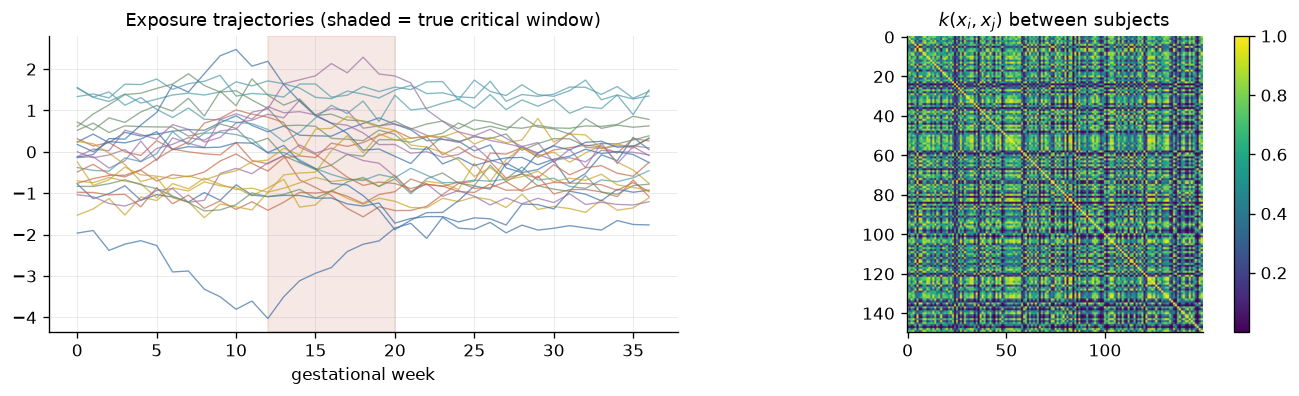

In [5]:
# Functional kernel on synthetic pregnancy exposure trajectories.
T = 37                                                   # weeks of gestation
t_grid = np.arange(T)
n_curves = 150

# each subject: a smooth baseline + a subject-specific bump
base = rng.normal(0, 1, size=(n_curves, 1)) * np.ones(T)
bump_c = rng.integers(5, 32, size=n_curves)
bump_h = rng.normal(0, 1.2, size=n_curves)
traj = base + bump_h[:, None] * np.exp(-0.5 * ((t_grid - bump_c[:, None]) / 4.0)**2)
traj += 0.15 * rng.normal(size=(n_curves, T))

# outcome driven ONLY by exposure during weeks 12-20 (a critical window; cf. Part 6)
window = (t_grid >= 12) & (t_grid <= 20)
y_fun = traj[:, window].mean(1) * 1.5 + 0.2 * rng.normal(size=n_curves)

Kf = functional_kernel(traj, traj, lengthscale=6.0)
_ = nk.psd_report("functional kernel", Kf)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for i in range(25):
    axes[0].plot(t_grid, traj[i], lw=0.8, alpha=0.7)
axes[0].axvspan(12, 20, color=nk.PALETTE["neg"], alpha=0.15)
axes[0].set_title("Exposure trajectories (shaded = true critical window)")
axes[0].set_xlabel("gestational week")
im = axes[1].imshow(Kf, cmap="viridis"); axes[1].grid(False)
axes[1].set_title("$k(x_i, x_j)$ between subjects")
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

---
## 3.2 Can we separate the contribution of each source?

Suppose exposures split into blocks by source — air, diet, noise. An **additive** kernel

$$
k(x,x') = \sum_{g} \sigma_g^2\, k_g\!\big(x^{(g)}, x'^{(g)}\big)
$$

corresponds to a function that decomposes as $f(x) = \sum_g f_g(x^{(g)})$, with each $f_g$ an
independent GP. Two large payoffs:

1. **Interpretability.** The posterior of each $f_g$ is available separately in closed form,
   so you can report the air-pollution contribution and the diet contribution individually.
2. **Statistical efficiency.** An additive model in $d$ dimensions needs far less data than a
   full $d$-dimensional RBF, which suffers badly from the curse of dimensionality.

The cost is the assumption itself: **no cross-source interactions**. §3.4 relaxes it.

The per-component posterior uses the same conditioning formula as always, with the
cross-covariance restricted to component $g$:
$\mathbb{E}[f_g(x_*)] = k_g(x_*, X)\,K_y^{-1}y$.

In [6]:
def make_additive_kernel(blocks, lengthscales, variances):
    """k(x,x') = sum_g var_g * RBF(x^(g), x'^(g); ell_g). blocks: list of column-index arrays."""
    def k(A, B):
        out = 0.0
        for cols, ell, v in zip(blocks, lengthscales, variances):
            out = out + nk.rbf_kernel(A[:, cols], B[:, cols], lengthscale=ell, variance=v)
        return out
    return k


def component_kernel(cols, ell, v):
    return lambda A, B: nk.rbf_kernel(A[:, cols], B[:, cols], lengthscale=ell, variance=v)


# Three exposure sources, each with its own true contribution.
n_add, sigma_add = 300, 0.25
air = rng.normal(size=(n_add, 2))
diet = rng.normal(size=(n_add, 2))
noise_x = rng.normal(size=(n_add, 1))
X_add = np.hstack([air, diet, noise_x])
blocks = [np.array([0, 1]), np.array([2, 3]), np.array([4])]

f_air = np.sin(1.5 * air[:, 0]) + 0.4 * air[:, 1]
f_diet = 0.6 * (diet[:, 0]**2 - 1.0)
f_noise = 0.9 * np.tanh(2 * noise_x[:, 0])
f_add = f_air + f_diet + f_noise
f_add -= f_add.mean()
y_add = f_add + sigma_add * rng.normal(size=n_add)

print(f"variance contributions -- air {f_air.var():.3f}  diet {f_diet.var():.3f}  "
      f"noise {f_noise.var():.3f}")

variance contributions -- air 0.683  diet 0.728  noise 0.507


In [7]:
# Fit the additive kernel by Type-II MLE over per-block lengthscales and variances.
def neg_lml_add(theta):
    p = np.exp(np.clip(theta, -8, 8))
    ells, vs, sn = p[:3], p[3:6], p[6]
    k = make_additive_kernel(blocks, ells, vs)
    try:
        return -GP(k, noise=sn).fit(X_add, y_add).lml()
    except np.linalg.LinAlgError:
        return 1e10

r_add = minimize(neg_lml_add, np.log(np.r_[np.ones(3), np.ones(3), 0.3]),
                 method="L-BFGS-B", options=dict(maxiter=500))
p_add = np.exp(r_add.x)
ells_hat, vs_hat, sn_hat = p_add[:3], p_add[3:6], p_add[6]

print(f"fitted lengthscales : {np.round(ells_hat, 3)}")
print(f"fitted noise        : {sn_hat:.3f}  (true {sigma_add})")
print(f"LML                 : {-r_add.fun:.2f}")

# The raw kernel variance is NOT comparable to var(f_g): a long lengthscale with a huge
# variance approximates a low-order polynomial, so the pair is only identified jointly.
# Compare the variance of the fitted component function instead.
gp_tmp = GP(make_additive_kernel(blocks, ells_hat, vs_hat), noise=sn_hat).fit(X_add, y_add)
print()
print(f"{'block':<8} {'raw var param':>14} {'var(f_g hat)':>14} {'true var(f_g)':>14}")
for nm_, cols_, ell_, v_, tr_ in zip(["air", "diet", "noise"], blocks, ells_hat, vs_hat,
                                     [f_air, f_diet, f_noise]):
    fg = component_kernel(cols_, ell_, v_)(X_add, X_add) @ gp_tmp.alpha_
    print(f"{nm_:<8} {v_:>14.2f} {fg.var():>14.3f} {tr_.var():>14.3f}")

# Compare against a single RBF over all 5 inputs.
def neg_lml_single(theta):
    p = np.exp(np.clip(theta, -8, 8))
    k = lambda A, B: nk.rbf_kernel(A, B, lengthscale=p[0], variance=p[1])
    try:
        return -GP(k, noise=p[2]).fit(X_add, y_add).lml()
    except np.linalg.LinAlgError:
        return 1e10

r_sing = minimize(neg_lml_single, np.log([1.0, 1.0, 0.3]), method="L-BFGS-B")
print(f"\nadditive kernel LML : {-r_add.fun:8.2f}")
print(f"single RBF     LML : {-r_sing.fun:8.2f}")
print(f"difference         : {(-r_add.fun) - (-r_sing.fun):8.2f} nats in favour of additive")

fitted lengthscales : [ 1.507 10.274  0.865]
fitted noise        : 0.239  (true 0.25)
LML                 : -81.15

block     raw var param   var(f_g hat)  true var(f_g)
air                1.49          0.727          0.683
diet            1078.04          0.751          0.728
noise              0.74          0.511          0.507

additive kernel LML :   -81.15
single RBF     LML :  -198.92
difference         :   117.77 nats in favour of additive


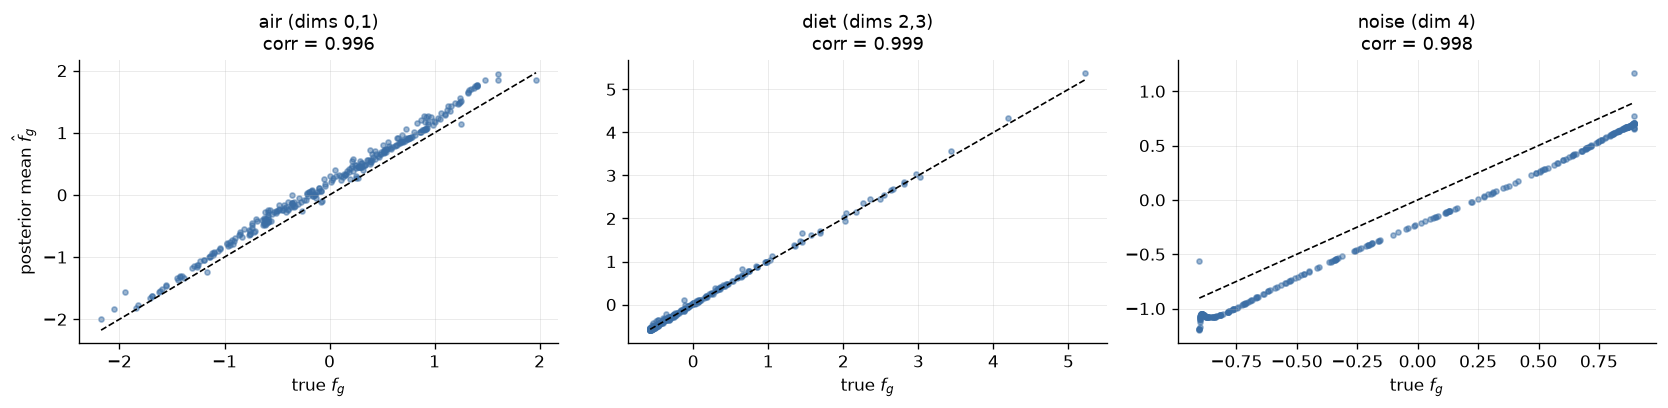

Each source's contribution is recovered separately from a single joint fit.


In [8]:
# Recover each component's posterior mean separately -- the interpretability payoff.
k_full = make_additive_kernel(blocks, ells_hat, vs_hat)
gp_add = GP(k_full, noise=sn_hat).fit(X_add, y_add)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
truths = [f_air, f_diet, f_noise]
names = ["air (dims 0,1)", "diet (dims 2,3)", "noise (dim 4)"]

for ax, cols, ell, v, truth, name in zip(axes, blocks, ells_hat, vs_hat, truths, names):
    kg = component_kernel(cols, ell, v)
    f_g_hat = kg(X_add, X_add) @ gp_add.alpha_          # E[f_g(X)] = K_g alpha
    truth_c = truth - truth.mean()
    ax.scatter(truth_c, f_g_hat, s=9, alpha=0.5, color=nk.PALETTE["pos"])
    lo, hi = truth_c.min(), truth_c.max()
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel("true $f_g$"); ax.set_title(f"{name}\ncorr = {np.corrcoef(truth_c, f_g_hat)[0,1]:.3f}")
axes[0].set_ylabel(r"posterior mean $\hat{f}_g$")
plt.tight_layout(); plt.show()

print("Each source's contribution is recovered separately from a single joint fit.")

### Try it 3. What has the additive kernel assumed?

The additive fit beat a single joint RBF by 118 nats and recovered each source's contribution separately. The fitted variance parameter for one block came out as 1078 while the *implied function* variance was 0.75.

1. State the assumption an additive kernel makes, and give one concrete exposome scenario where it is wrong.
2. Why did the raw variance parameter of 1078 not mean the diet block dominates? What was actually going on?
3. Given (2), what should you report in a paper — the kernel hyperparameters or something else?
4. The 118-nat gap partly reflects the curse of dimensionality. Explain why an additive model needs less data than a joint one.

**Your answer**

*(write here)*

---
## 3.3 What if we measured several outcomes?

Sometimes several *outcomes* are measured on the same subjects (birth weight, gestational
age, a cognitive score) and they share structure. The **intrinsic coregionalisation model**
(ICM) factorises the covariance as

$$
k\big((x, t), (x', t')\big) = B_{t t'} \cdot k_x(x, x'),
\qquad B = WW^\top + \operatorname{diag}(\kappa),
$$

i.e. a Kronecker product $K = B \otimes K_x$. $B$ is the $T\times T$ **task covariance**; the
$WW^\top + \operatorname{diag}(\kappa)$ form guarantees it is PSD while keeping the number of
parameters low. Learning $B$ lets a data-rich task lend strength to a data-poor one —
directly useful when one outcome has far fewer measurements than another.

In [9]:
def icm_kernel(Xa, ta, Xb, tb, B, lengthscale=1.0):
    """Intrinsic coregionalisation: k((x,t),(x',t')) = B[t,t'] * k_x(x,x')."""
    return B[np.asarray(ta).ravel()[:, None], np.asarray(tb).ravel()[None, :]] \
        * nk.rbf_kernel(Xa, Xb, lengthscale=lengthscale)


# Two correlated outcomes; task 1 is severely under-sampled.
n_t0, n_t1 = 80, 12
x0 = np.sort(rng.uniform(-3, 3, n_t0))[:, None]
x1 = np.sort(rng.uniform(-3, 3, n_t1))[:, None]

g_shared = lambda x: np.sin(1.3 * x).ravel()
y0 = g_shared(x0) + 0.15 * rng.normal(size=n_t0)
y1 = 1.4 * g_shared(x1) + 0.4 + 0.15 * rng.normal(size=n_t1)     # scaled + shifted version

X_mt = np.vstack([x0, x1])
t_mt = np.r_[np.zeros(n_t0, int), np.ones(n_t1, int)]
y_mt = np.r_[y0, y1]

def neg_lml_icm(theta):
    w = theta[:2]; kap = np.exp(np.clip(theta[2:4], -8, 4))
    ell, sn = np.exp(np.clip(theta[4], -4, 4)), np.exp(np.clip(theta[5], -6, 2))
    B = np.outer(w, w) + np.diag(kap)
    K = icm_kernel(X_mt, t_mt, X_mt, t_mt, B, ell) + sn**2 * np.eye(len(y_mt))
    try:
        L = np.linalg.cholesky(0.5 * (K + K.T) + 1e-8 * np.eye(len(y_mt)))
    except np.linalg.LinAlgError:
        return 1e10
    yc = y_mt - y_mt.mean()
    a = np.linalg.solve(L.T, np.linalg.solve(L, yc))
    return float(0.5 * yc @ a + np.log(np.diag(L)).sum())

r_icm = minimize(neg_lml_icm, np.r_[1.0, 1.0, np.log([0.1, 0.1]), np.log(1.0), np.log(0.2)],
                 method="L-BFGS-B", options=dict(maxiter=1000))
w_h, kap_h = r_icm.x[:2], np.exp(r_icm.x[2:4])
B_hat = np.outer(w_h, w_h) + np.diag(kap_h)
ell_h, sn_h = np.exp(r_icm.x[4]), np.exp(r_icm.x[5])

corr_tasks = B_hat[0, 1] / np.sqrt(B_hat[0, 0] * B_hat[1, 1])
print(f"learned task covariance B:\n{np.round(B_hat, 3)}")
print(f"implied task correlation : {corr_tasks:+.3f}")
print(f"lengthscale {ell_h:.3f}   noise {sn_h:.3f}")
print(f"B is PSD: {nk.is_psd(B_hat)}")

learned task covariance B:
[[1.973 2.821]
 [2.821 4.201]]
implied task correlation : +0.980
lengthscale 1.745   noise 0.162
B is PSD: True


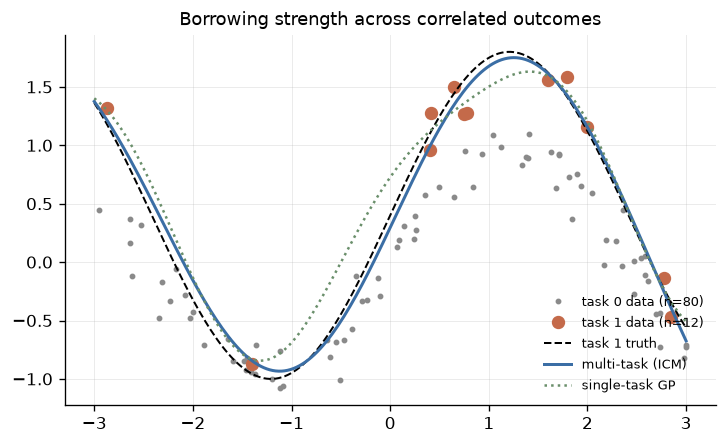

RMSE on task 1 -- multi-task 0.0880   single-task 0.2163


In [10]:
# Does borrowing strength actually help the data-poor task?
xs_mt = np.linspace(-3, 3, 200)[:, None]

def icm_predict(task):
    K = icm_kernel(X_mt, t_mt, X_mt, t_mt, B_hat, ell_h) + sn_h**2 * np.eye(len(y_mt))
    L, _ = nk.jitter_chol(K)
    yc = y_mt - y_mt.mean()
    a = np.linalg.solve(L.T, np.linalg.solve(L, yc))
    Ks = icm_kernel(X_mt, t_mt, xs_mt, np.full(len(xs_mt), task), B_hat, ell_h)
    return Ks.T @ a + y_mt.mean()

# independent single-task GP on task 1 only, for comparison
def st_lml(theta):
    p = np.exp(np.clip(theta, -6, 4))
    k = lambda A, B_: nk.rbf_kernel(A, B_, lengthscale=p[0], variance=p[1])
    try:
        return -GP(k, noise=p[2]).fit(x1, y1).lml()
    except np.linalg.LinAlgError:
        return 1e10
r_st = minimize(st_lml, np.log([1.0, 1.0, 0.2]), method="L-BFGS-B")
p_st = np.exp(r_st.x)
gp_st = GP(lambda A, B_: nk.rbf_kernel(A, B_, lengthscale=p_st[0], variance=p_st[1]),
           noise=p_st[2]).fit(x1, y1)
mu_st, _ = gp_st.predict(xs_mt)

truth1 = 1.4 * g_shared(xs_mt) + 0.4
mu_icm = icm_predict(1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x0, y0, ".", color=nk.PALETTE["muted"], ms=5, label=f"task 0 data (n={n_t0})")
ax.plot(x1, y1, "o", color=nk.PALETTE["neg"], ms=7, label=f"task 1 data (n={n_t1})")
ax.plot(xs_mt, truth1, "k--", lw=1.2, label="task 1 truth")
ax.plot(xs_mt, mu_icm, color=nk.PALETTE["pos"], lw=1.8, label="multi-task (ICM)")
ax.plot(xs_mt, mu_st, color=nk.PALETTE["accent"], lw=1.5, ls=":", label="single-task GP")
ax.legend(fontsize=8); ax.set_title("Borrowing strength across correlated outcomes")
plt.show()

print(f"RMSE on task 1 -- multi-task {np.sqrt(np.mean((mu_icm - truth1)**2)):.4f}"
      f"   single-task {np.sqrt(np.mean((mu_st - truth1)**2)):.4f}")

### Try it 4. When is borrowing strength a good idea?

The multi-task fit halved the error on the 12-observation task by learning a task correlation of 0.98 with the 80-observation task.

1. What would have happened if the two tasks had been *unrelated*? Would the model have been harmed, and what protects it?
2. The ICM kernel is $B \otimes K_x$ with $B = WW^\top + \text{diag}(\kappa)$. Which closure rule from NB-1 §1.4 guarantees this is PSD?
3. Give one situation in exposome research where sharing across outcomes would be scientifically *inappropriate*, even if it improved prediction.

**Your answer**

*(write here)*

---
## 3.4 How do we allow interactions without allowing everything?

**Tensor product.** Multiplying per-dimension kernels,
$k(x,x') = \prod_j k_j(x_j, x'_j)$, gives a function space containing *all* interaction
orders. The plain RBF is already of this form. It is maximally flexible and therefore
statistically expensive.

**ANOVA kernels** sit between the additive (3.2) and tensor-product extremes by expanding
the product and keeping terms up to a chosen order:

$$
\prod_{j=1}^{d}\big(1 + k_j\big) = \underbrace{1}_{\text{const}}
+ \underbrace{\sum_j k_j}_{\text{main effects}}
+ \underbrace{\sum_{j<l} k_j k_l}_{\text{2-way}}
+ \cdots
$$

Truncating after 2-way terms says: main effects and pairwise interactions, nothing higher.
For mixtures research that is often exactly the scientific question — *do these two
pollutants interact?* — and the decomposition makes each term separately estimable.

The elementary symmetric polynomials $e_m$ give the terms, and the **Newton–Girard
recursion** computes them in $O(d^2)$ rather than enumerating $\binom{d}{m}$ subsets:

$$
e_m = \frac{1}{m}\sum_{i=1}^{m} (-1)^{i-1} e_{m-i}\, p_i,
\qquad p_i = \sum_j k_j^{\,i}.
$$

In [11]:
def anova_kernel(A, B, max_order=2, lengthscale=1.0, variances=None):
    """ANOVA kernel of given interaction order, via Newton-Girard on per-dim kernels."""
    A, B = np.atleast_2d(A), np.atleast_2d(B)
    d = A.shape[1]
    v = np.ones(d) if variances is None else np.asarray(variances, float)

    ks = np.stack([nk.rbf_kernel(A[:, [j]], B[:, [j]], lengthscale=lengthscale, variance=v[j])
                   for j in range(d)])                                  # (d, n, m)

    power = [None] + [np.sum(ks**i, axis=0) for i in range(1, max_order + 1)]
    e = [np.ones_like(ks[0])]
    for m in range(1, max_order + 1):
        acc = np.zeros_like(ks[0])
        for i in range(1, m + 1):
            acc += (-1)**(i - 1) * e[m - i] * power[i]
        e.append(acc / m)
    return e, ks                                     # e[0]=1, e[1]=additive, e[2]=2-way, ...


def anova_gram(A, B, max_order=2, lengthscale=1.0, variances=None, weights=None):
    e, _ = anova_kernel(A, B, max_order, lengthscale, variances)
    w = np.ones(max_order + 1) if weights is None else np.asarray(weights, float)
    return sum(w[m] * e[m] for m in range(max_order + 1))


# Verify Newton-Girard against brute-force enumeration of subsets.
from itertools import combinations
A_t = rng.normal(size=(12, 4))
e_t, ks_t = anova_kernel(A_t, A_t, max_order=3, lengthscale=1.0)
for m in [1, 2, 3]:
    brute = sum(np.prod([ks_t[j] for j in S], axis=0) for S in combinations(range(4), m))
    print(f"order {m}: max |Newton-Girard - brute force| = {np.abs(e_t[m] - brute).max():.2e}")

# Order-d ANOVA with all weights 1 must equal the tensor product prod(1 + k_j).
e_full, ks_full = anova_kernel(A_t, A_t, max_order=4, lengthscale=1.0)
tensor = np.prod(1.0 + ks_full, axis=0)
print(f"sum_m e_m  vs  prod_j (1+k_j): max diff = "
      f"{np.abs(sum(e_full) - tensor).max():.2e}")

order 1: max |Newton-Girard - brute force| = 0.00e+00
order 2: max |Newton-Girard - brute force| = 2.66e-15
order 3: max |Newton-Girard - brute force| = 2.22e-15
sum_m e_m  vs  prod_j (1+k_j): max diff = 3.55e-15


In [12]:
# Does the ANOVA order matter? Data with main effects + ONE 2-way interaction.
n_an, d_an = 250, 4
X_an = rng.uniform(-2, 2, size=(n_an, d_an))
f_main = np.sin(1.2 * X_an[:, 0]) + 0.5 * X_an[:, 1]**2
f_inter = 0.9 * X_an[:, 0] * X_an[:, 2]                       # the interaction to detect
f_an = f_main + f_inter
f_an -= f_an.mean()
y_an = f_an + 0.2 * rng.normal(size=n_an)

print(f"{'model':<26} {'LML':>9}  {'kernel order'}")
results = {}
for order, name in [(1, "additive (order 1)"), (2, "ANOVA order 2"), (3, "ANOVA order 3"),
                    (4, "ANOVA order 4 = tensor")]:
    def nl(theta, order=order):
        p = np.exp(np.clip(theta, -6, 5))
        k = lambda A, B: anova_gram(A, B, max_order=order, lengthscale=p[0],
                                    weights=np.r_[0.0, p[1:1+order]])
        try:
            return -GP(k, noise=p[-1]).fit(X_an, y_an).lml()
        except np.linalg.LinAlgError:
            return 1e10
    r_ = minimize(nl, np.log(np.r_[1.0, np.ones(order), 0.3]), method="L-BFGS-B",
                  options=dict(maxiter=400))
    results[name] = -r_.fun
    print(f"{name:<26} {-r_.fun:>9.2f}  {order}")

best_name = max(results, key=results.get)
print(f"\nbest by LML: {best_name}")
print(f"order 2 is within {results[best_name] - results['ANOVA order 2']:.2f} nats of it")

model                            LML  kernel order


additive (order 1)           -417.81  1


ANOVA order 2                 -36.05  2


ANOVA order 3                 -34.65  3


ANOVA order 4 = tensor        -34.62  4

best by LML: ANOVA order 4 = tensor
order 2 is within 1.43 nats of it


Order 1 is catastrophically worse (~380 nats) because an additive model simply cannot
represent $x_0 x_2$. Orders 2, 3 and 4 are within ~1.4 nats of each other — which is the
right answer, since the truth contains only a 2-way interaction and there is nothing for the
higher orders to find. A difference of one or two nats is not evidence for extra structure.

The practical reading: **the marginal likelihood identifies the interaction order that
matters and is indifferent above it**. Choosing order 2 here costs essentially nothing in
fit and buys a model whose terms you can actually report — which is the next cell.

### Try it 5. Which interaction order would you report?

Order 1 lost by ~380 nats. Orders 2, 3 and 4 were within 1.4 nats of each other, and the truth contained only a 2-way interaction.

1. Why is the huge gap between order 1 and order 2 informative, while the tiny gap between orders 2 and 4 is not?
2. Order 4 technically had the best score. Give two reasons to report order 2 anyway.
3. The number of pairwise terms grows as $\binom{M}{2}$. For a 20-exposure mixture, how many are there — and what does that imply about testing each one?
4. The isolated pairwise strengths ranked the true $x_0 x_2$ term first at 1.51, with the runner-up at 0.33. Is that gap convincing? What would make you more confident?

**Your answer**

*(write here)*

### How do we read an interaction off the fit?

Because the ANOVA expansion is a *sum* of terms, the posterior decomposes the same way as
in 3.2. The order-2 block $e_2$ carries all pairwise interactions, and restricting it to a
single pair $(j,l)$ isolates that interaction's contribution — a direct estimate of the kind
of two-pollutant synergy that BKMR reports in 6.3.

In [13]:
# Isolate pairwise contributions using the fitted order-2 model.
def nl2(theta):
    p = np.exp(np.clip(theta, -6, 5))
    k = lambda A, B: anova_gram(A, B, max_order=2, lengthscale=p[0], weights=np.r_[0.0, p[1], p[2]])
    try:
        return -GP(k, noise=p[3]).fit(X_an, y_an).lml()
    except np.linalg.LinAlgError:
        return 1e10

r2 = minimize(nl2, np.log([1.0, 1.0, 1.0, 0.3]), method="L-BFGS-B", options=dict(maxiter=600))
p2 = np.exp(r2.x)
k2 = lambda A, B: anova_gram(A, B, max_order=2, lengthscale=p2[0], weights=np.r_[0.0, p2[1], p2[2]])
gp_an = GP(k2, noise=p2[3]).fit(X_an, y_an)

ks_all = np.stack([nk.rbf_kernel(X_an[:, [j]], X_an[:, [j]], lengthscale=p2[0])
                   for j in range(d_an)])
print("pairwise interaction strength (variance of the isolated component):")
strengths = {}
for j, l in combinations(range(d_an), 2):
    Kjl = p2[2] * ks_all[j] * ks_all[l]
    f_jl = Kjl @ gp_an.alpha_
    strengths[(j, l)] = f_jl.var()
for (j, l), s in sorted(strengths.items(), key=lambda kv: -kv[1]):
    flag = "  <-- true interaction" if (j, l) == (0, 2) else ""
    print(f"  x{j} * x{l} : {s:.4f}{flag}")

pairwise interaction strength (variance of the isolated component):
  x0 * x2 : 1.5130  <-- true interaction
  x1 * x2 : 0.3322
  x0 * x1 : 0.1246
  x0 * x3 : 0.1124
  x1 * x3 : 0.0812
  x2 * x3 : 0.0421


---
## 3.5 What if similarity is a network, not a distance?

Social contact and mobility networks are graphs, and "similarity" there means *proximity in
the graph*, not Euclidean distance. The standard construction starts from the **graph
Laplacian** $L = D - A$ ($D$ degree, $A$ adjacency), which is PSD by construction with
$c^\top L c = \sum_{(i,j)\in E}(c_i - c_j)^2 \ge 0$.

Two standard kernels, both PSD because they are functions of $L$ with non-negative spectra:

| Kernel | Form | Interpretation |
|---|---|---|
| Regularised Laplacian | $(I + \beta L)^{-1}$ | one-step diffusion / graph ridge |
| Diffusion (heat) | $\exp(-\beta L)$ | continuous random walk for time $\beta$ |

Both say: nodes connected by many short paths are similar. $\beta$ is a lengthscale in graph
space and is learned exactly like any other hyperparameter.

In [14]:
from scipy.linalg import expm

def graph_laplacian(A_adj, normalized=False):
    deg = A_adj.sum(1)
    L = np.diag(deg) - A_adj
    if normalized:
        dinv = 1.0 / np.sqrt(np.maximum(deg, 1e-12))
        L = dinv[:, None] * L * dinv[None, :]
    return L

def regularized_laplacian_kernel(A_adj, beta=1.0, normalized=False):
    L = graph_laplacian(A_adj, normalized)
    return np.linalg.inv(np.eye(len(L)) + beta * L)

def diffusion_kernel(A_adj, beta=1.0, normalized=False):
    return expm(-beta * graph_laplacian(A_adj, normalized))


# A small community-structured network (stochastic block model).
n_nodes, n_comm = 60, 3
comm = np.repeat(np.arange(n_comm), n_nodes // n_comm)
p_in, p_out = 0.35, 0.02
P = np.where(comm[:, None] == comm[None, :], p_in, p_out)
A_adj = (rng.uniform(size=(n_nodes, n_nodes)) < P).astype(float)
A_adj = np.triu(A_adj, 1); A_adj = A_adj + A_adj.T

Lap = graph_laplacian(A_adj)
_ = nk.psd_report("graph Laplacian L", Lap)
_ = nk.psd_report("regularised Laplacian kernel", regularized_laplacian_kernel(A_adj, beta=1.0))
_ = nk.psd_report("diffusion kernel beta=0.5", diffusion_kernel(A_adj, beta=0.5))
print(f"\nL has {np.sum(np.linalg.eigvalsh(Lap) < 1e-9)} zero eigenvalue(s) "
      f"= number of connected components")

graph Laplacian L                    lambda_min = -1.344e-15   rank  58/60   PSD  ok
regularised Laplacian kernel         lambda_min = +5.675e-02   rank  60/60   PSD  ok
diffusion kernel beta=0.5            lambda_min = +2.460e-04   rank  60/60   PSD  ok

L has 2 zero eigenvalue(s) = number of connected components


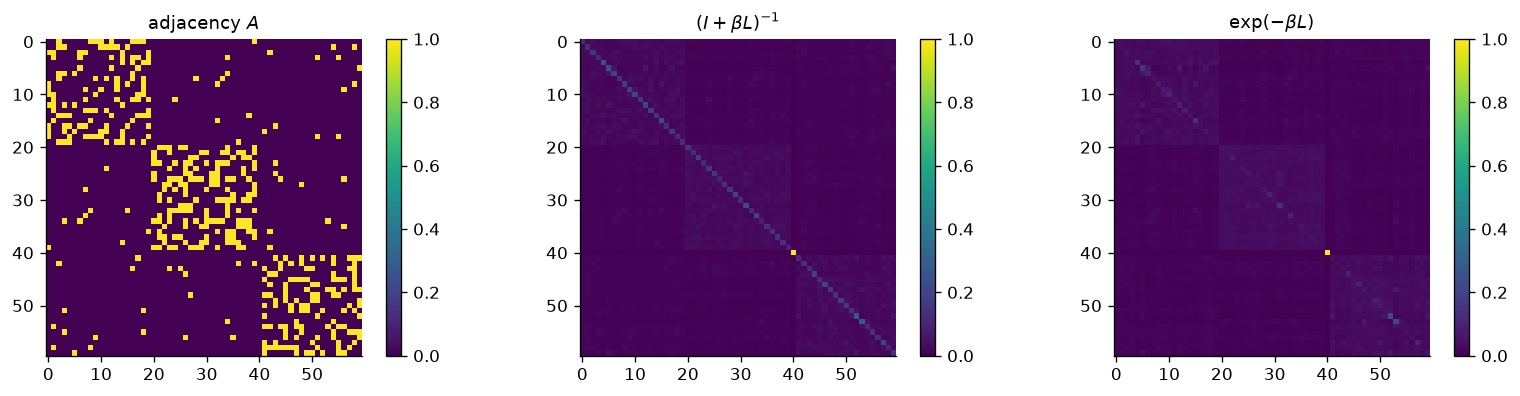

                    within   between   ratio   within-pairs with 0 similarity
adjacency           0.3368    0.0258   13.04                           66.3%
reg. Laplacian      0.0241    0.0093    2.60                            3.3%
diffusion           0.0295    0.0089    3.31                            3.3%


In [15]:
K_diff = diffusion_kernel(A_adj, beta=0.6)
K_reg = regularized_laplacian_kernel(A_adj, beta=1.0)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4))
for ax, M, t in [(axes[0], A_adj, "adjacency $A$"),
                 (axes[1], K_reg, r"$(I+\beta L)^{-1}$"),
                 (axes[2], K_diff, r"$\exp(-\beta L)$")]:
    im = ax.imshow(M, cmap="viridis"); ax.grid(False); ax.set_title(t)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

# Do the kernels recover community structure that the raw adjacency does not show?
same = comm[:, None] == comm[None, :]
off = ~np.eye(n_nodes, dtype=bool)
print(f"{'':<16} {'within':>9} {'between':>9} {'ratio':>7} {'within-pairs with 0 similarity':>32}")
for name, M in [("adjacency", A_adj), ("reg. Laplacian", K_reg), ("diffusion", K_diff)]:
    within = M[same & off].mean()
    between = M[~same].mean()
    zero_frac = np.mean(M[same & off] < 1e-8)
    print(f"{name:<16} {within:>9.4f} {between:>9.4f} {within/max(between,1e-12):>7.2f} "
          f"{zero_frac:>31.1%}")

Read the last column, not the ratio. The adjacency matrix has a *higher* within/between
ratio simply because it is binary and sparse — but it leaves **66% of same-community pairs
with zero similarity**, since most nodes in a community are not directly connected. The
diffusion and regularised-Laplacian kernels reach nearly all of them by accumulating
indirect paths. That is the property that makes them useful for prediction, which the next
cell tests.

### Try it 6. Why not just use the adjacency matrix?

The adjacency matrix had a *better* within/between ratio (13.0 vs 3.3) yet left 66% of same-community pairs at zero similarity, against 3% for the diffusion kernel.

1. Explain why a high ratio can coexist with being useless for prediction.
2. What does the diffusion kernel know that the adjacency matrix does not?
3. $\beta$ behaves like a lengthscale in graph space. Predict what happens to the kernel as $\beta \to 0$ and as $\beta \to \infty$, then check against the RMSE sweep.
4. The Laplacian had 2 zero eigenvalues. What does that tell you about the network, and why should you check it before modelling?

**Your answer**

*(write here)*

In [16]:
# Use the graph kernel for prediction: a node-level outcome that varies by community.
y_graph = np.array([-1.0, 0.3, 1.2])[comm] + 0.35 * rng.normal(size=n_nodes)

idx = rng.permutation(n_nodes)
tr_idx, te_idx = idx[:30], idx[30:]

def graph_gp_rmse(K):
    Ktr = K[np.ix_(tr_idx, tr_idx)] + 0.35**2 * np.eye(len(tr_idx))
    L_, _ = nk.jitter_chol(Ktr)
    ym = y_graph[tr_idx].mean()
    a = np.linalg.solve(L_.T, np.linalg.solve(L_, y_graph[tr_idx] - ym))
    pred = K[np.ix_(tr_idx, te_idx)].T @ a + ym
    return np.sqrt(np.mean((pred - y_graph[te_idx])**2))

print(f"{'kernel':<26} {'test RMSE':>10}")
print(f"{'predict the mean':<26} {np.sqrt(np.mean((y_graph[te_idx] - y_graph[tr_idx].mean())**2)):>10.4f}")
for b in [0.1, 0.3, 0.6, 1.5, 4.0]:
    print(f"{'diffusion beta=' + str(b):<26} {graph_gp_rmse(diffusion_kernel(A_adj, beta=b)):>10.4f}")
print(f"{'reg. Laplacian beta=1':<26} {graph_gp_rmse(regularized_laplacian_kernel(A_adj, 1.0)):>10.4f}")

kernel                      test RMSE
predict the mean               1.0283
diffusion beta=0.1             0.8596
diffusion beta=0.3             0.6922
diffusion beta=0.6             0.6484
diffusion beta=1.5             0.7854
diffusion beta=4.0             1.0149
reg. Laplacian beta=1          0.7766


---
## 3.6 Can we put it all in one covariance?

The real payoff is composing all of the above into a single covariance. For a cohort with
continuous exposures, a categorical site, an ordinal education level, and a functional
pregnancy trajectory:

$$
k = \underbrace{\sigma_1^2 k_{\text{air}}(x^{\text{air}})
+ \sigma_2^2 k_{\text{diet}}(x^{\text{diet}})}_{\text{additive sources (3.2)}}
+ \underbrace{\sigma_3^2 k_{\text{cat}}(\text{site})}_{\text{3.1}}
\;\cdot\; \underbrace{k_{\text{ord}}(\text{edu})}_{\text{3.1, modifies}}
+ \underbrace{\sigma_4^2 k_{\text{func}}(x(t))}_{\text{3.1}}
$$

Sums for independent contributions, products for effect modification. Every piece is PSD,
so by the closure rules the whole is PSD — which we verify rather than assume.

In [17]:
n_mix = 240
mix_air = rng.normal(size=(n_mix, 2))
mix_diet = rng.normal(size=(n_mix, 2))
mix_site = rng.integers(0, 3, size=n_mix)
mix_edu = rng.integers(0, 4, size=n_mix)
mix_traj = (rng.normal(0, 1, (n_mix, 1)) * np.ones(T)
            + rng.normal(0, 1.0, (n_mix, 1)) * np.exp(-0.5 * ((t_grid - 16) / 5.0)**2))

def mixed_kernel(idx_a, idx_b):
    """Compose the full covariance. Args are index arrays into the cohort arrays."""
    ia, ib = np.asarray(idx_a).ravel(), np.asarray(idx_b).ravel()
    k_air = nk.rbf_kernel(mix_air[ia], mix_air[ib], lengthscale=1.2, variance=1.0)
    k_diet = nk.rbf_kernel(mix_diet[ia], mix_diet[ib], lengthscale=1.5, variance=0.6)
    k_site = categorical_kernel(mix_site[ia], mix_site[ib], rho=0.3)
    k_edu = ordinal_kernel(mix_edu[ia], mix_edu[ib], [0, 0.4, 1.6, 2.0], lengthscale=1.0)
    k_fun = functional_kernel(mix_traj[ia], mix_traj[ib], lengthscale=6.0, variance=0.8)
    return k_air + k_diet + 0.5 * (k_site * k_edu) + k_fun

all_idx = np.arange(n_mix)
K_mix = mixed_kernel(all_idx, all_idx)
ev = nk.psd_report("composed mixed-type kernel", K_mix)

print()
for nm, M in [("  air", nk.rbf_kernel(mix_air, mix_air, lengthscale=1.2)),
              ("  site x edu (product)",
               categorical_kernel(mix_site, mix_site, 0.3)
               * ordinal_kernel(mix_edu, mix_edu, [0, 0.4, 1.6, 2.0])),
              ("  functional", functional_kernel(mix_traj, mix_traj, lengthscale=6.0))]:
    _ = nk.psd_report(nm, M, verbose=True)

print(f"\nComposition is PSD because every piece is, and sums/products preserve it (1.4).")
print("Each piece is individually low-rank -- a categorical kernel on 3 levels can only")
print("have rank 3 -- and summing them builds back up to a usable covariance.")

composed mixed-type kernel           lambda_min = +1.734e-11   rank 193/240   PSD  ok

  air                                lambda_min = -5.491e-15   rank  85/240   PSD  ok
  site x edu (product)               lambda_min = -3.433e-14   rank  12/240   PSD  ok
  functional                         lambda_min = -1.781e-14   rank  62/240   PSD  ok

Composition is PSD because every piece is, and sums/products preserve it (1.4).
Each piece is individually low-rank -- a categorical kernel on 3 levels can only
have rank 3 -- and summing them builds back up to a usable covariance.


### Try it 7. Design a kernel for a cohort you care about.

The composed kernel used sums for independent sources and a product for effect modification, and stayed PSD because every piece was.

1. In the composition, `site` and `education` were combined with a **product**, while air and diet were **summed**. Explain the modelling difference in words.
2. Each individual component was low-rank (the categorical kernel on 3 levels has rank 3). Why is the sum still usable?
3. Now write down — in notation, not code — a kernel for a cohort of your own. Name at least four variables of different types, and say for each pair whether you would sum or multiply, and why.
4. What single numerical check would you run on your design before fitting anything?

**Your answer**

*(write here)*

## What can we conclude?

Three closure rules were enough to build a covariance for categorical, ordinal, functional, blocked, multi-output and network-structured data — and to combine them into one model. Nothing here required new mathematics; it required deciding what "similar" should mean for each kind of variable.

| What we built | Where it is used next |
|---|---|
| **Additive** kernels with per-source posteriors | NB-6 §6.5, multi-pollutant models; the additive-BKMR variants |
| **ANOVA** kernels: main effects plus pairwise | NB-6 §6.3 — this is the structure BKMR estimates |
| **Functional** kernels over curves | NB-6 §6.1–6.2, once the weighting over time gets its own prior |
| **Multi-task** kernels | sharing across correlated outcomes, e.g. multi-omics panels |
| PSD checking as a habit | every kernel you invent from here on |

One limitation to carry forward: everything here used fixed hyperparameters or a flat Type-II MLE. NB-4 puts *priors* on them, and NB-5 makes the choice of which components to include an explicit, probabilistic decision.

## What should you submit?

- Run every code cell from top to bottom.
- Write something in your own words in **Try it 1–7**. Try it 7 is the important one: it asks you to design a kernel rather than read one.
- Change one composition in §3.6 — swap a sum for a product, or drop a component — and report what happened to the PSD check and the effective rank.

**Going further (optional)**

1. Learn $\rho$ in the categorical kernel by Type-II MLE and see whether the optimiser respects the PSD boundary $\rho \ge -1/(L-1)$. What happens if you do not constrain it?
2. Extend §3.3 to a **linear model of coregionalisation** — a sum of ICM terms with different lengthscales — so tasks can share short-range but not long-range structure.
3. Write a sequence kernel for residential history coded as a string of area types, and check PSD numerically.
4. Put a sparsity prior on the order-2 ANOVA weights so only a few pairwise interactions survive — a preview of NB-5 §5.3.
5. Learn the diffusion kernel's $\beta$ by marginal likelihood and compare it with the RMSE-optimal value from the sweep. Do they agree?

*NB-4 stops treating the kernel's form as fixed: the warping, the smoothness and the shrinkage all become things to learn.*